# Helical acquisition and reconstruction testing

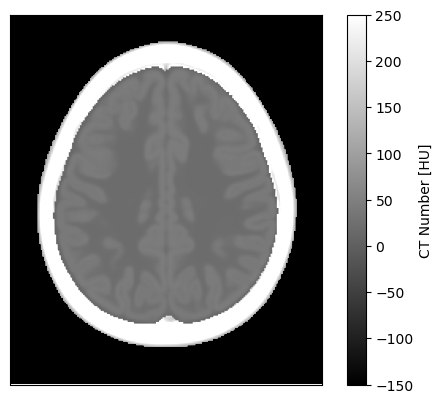

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from pedsilicoICH.ground_truth_definition.phantoms import NIHPD_Head, MIDA_Head

from utils import ctshow

nihpd_dir = Path('../NIHPD_Head_Phantom')
nihpd = NIHPD_Head(nihpd_dir, age=11.5)

im = ctshow(nihpd.get_CT_number_phantom()[80])
plt.colorbar(im, label='CT Number [HU]')

In [2]:
from pedsilicoICH.image_acquisition import Scanner

nihpd.patient_name = 'helical_test'
scanner = Scanner(nihpd)
scanner

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 1.0-mm pixels (XY), 1.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 189 slices...
* Writing volume fraction files for 4 materials and 189 slices, plus the HU data...
* Writing helical_test/phantoms/0/0_ncat_ad


        <class 'pedsilicoICH.image_acquisition.Scanner'> default
        Scanner: CATSIM
        

In [3]:
import gecatsim as xc
from gecatsim.reconstruction.pyfiles import recon

##--------- Initialize 
ct = xc.CatSim("../src/pedsilicoICH/defaults/helical_cfg/Phantom_Sample_Analytic",
               "../src/pedsilicoICH/defaults/helical_cfg/Protocol_Sample_Helical",
               "../src/pedsilicoICH/defaults/helical_cfg/Scanner_Sample_generic",
               "../src/pedsilicoICH/defaults/helical_cfg/Physics_Sample",
               "../src/pedsilicoICH/defaults/helical_cfg/Recon_Sample_Helical",
        )  # initialization

##--------- Make changes to parameters (optional)
# ct.phantom.filename = 'water20.ppm'
#ct.phantom.filename = 'CTDI_16cm_WaterAirPEBoneChambers.ppm'
ct.phantom.filename = '/home/jayse.weaver/PedSilicoICH/notebooks/helical_test/phantoms/0/0.json'
ct.resultsName = "test_Helical"

print(ct.protocol.startZ)
ct.protocol.startZ = -75
print(ct.protocol.startZ)

##--------- Run simulation
ct.run_all()  # run the scans defined by protocol.scanTypes


if ct.physics.monochromatic>0:
        ct.recon.mu = xc.GetMu('water', ct.physics.monochromatic)[0]/10

cfg = ct.get_current_cfg()

-12.79
-75
Airscan
Offset scan
Phantom scan


  0%|          | 0/2500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 2500/2500 [12:36<00:00,  3.30it/s]


Prep view
Applying LSC...done.

Simulation is done.


In [4]:
print(cfg.recon.sliceThickness)

cfg.do_Recon = 1
cfg.waitForKeypress = 0
recon.recon(cfg)

5
* Loading the projection data...
* Rebinning the projection...
* Applying the filter...
* Reconstruction parameters:
* SID: 540.0 mm
* SDD: 950.0 mm
* Fan angle: 0.947368323802948 degrees
* Number of detector cols: 900
* Number of detector rows: 16
* Detector height: 16.0 mm
* Detector X offset: -0.25 mm
* Detector Z offset: 0.0 mm
* Scan number of views: 2500 
* Recon FOV: 250.0 mm
* Recon XY pixel size: 512 mm
* Recon Slice thickness: 5.0 mm
* Recon X offset: -0.0 mm
* Recon Y offset: 0.0 mm
* Recon Z offset: 0.0 mm
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
   recon slice 0/30...
   recon slice 1/30...
   recon slice 2/30...
   recon slice 3/30...
   recon slice 4/30...
   recon slice 5/30...
   recon slice 6/30...
   recon slice 7/30...
   recon slice 8/30...
   recon slice 9/30...
   recon slice 10/30...
   recon slice 11/30...
   recon slice 12/30...
   recon slice 13/30...
   recon slice 14/30...
  